# ISYE 524 Project: 
# <center> **Optimal Reverse Supply Chain**: </center>
## <center> Modeling Multi-Echelon, Multi-Indenture Systems </center>
---
## Professor: Amanda Smith
## Project Members: Seth Ockerman and Mitchell Stachowiak
### University of Wisconsin - Madison
### Spring 2026
---
# <center><u> Report </u></center>

---
# <center>Introduction</center>

[The first few sentences should give a quick overview of the entire project. Then, elaborate with a description of the problem that will be solved, a brief history (with citations, if appropriate) of how the problem came about, why it’s important/interesting, and any other interesting facts you’d like to talk about. You should address and explain where the problem data is coming from (research? the internet? synthetically generated?) Also give an outline of the rest of the report. Include any assumptions you are making to simplify the problem. This section should be accessible to someone that has not taken this course.]


The project seeks to model the problem of optimally fulfilling demands of a **reverse supply** chain which is **multi-echelon** and **multi-indenture** by using the tooling of linear and integer optimization.

The project was inspired by the work of Craig C. Sherbrooke, in particular his work in developing marginal analysis tools like the METRIC model for the USAF as well as his textbook *Optimal Inventory Modeling of Systems: Multi-Echelon Techniques*; however, we implement our models using LP methods rather than Sherbrooke's marginal approach. Moreover, while his work considered defense applications, our work expands to problems faced in the commercial sector such as commercial aviation or trucking where the same low demand and high cost assumptions can be applied. In these areas, it is critical to prevent misallocation of demands and resources as turnarounds are usually slow, mistakes are costly, and inefficiencies can easily compound into other sectors (e.g. commerce, travel, defense).

Our project considers the motivating example of repair logistics; specifically, we will consider how to optimally repair components of aircraft. Given the relative sparsity of aircraft relative to that of automobiles, some components are produced to order, with relatively small inventory buffer if any; moreover, the manufacture of such equipment is prohibitively expensive and time-consuming if mechanics are required to constantly order new components for repairs; thus, repairs are prioratized to minimize cost of maintenance and down-time of aircraft.

A **reverse supply-chain** is a supply-chain in which customers generate demand for repair or refurbishment services rather than consumption of new products. In our motivating example, failed components are returned, diagnosed, and repaired through a network rather than purchasing new components like in a traditional supply-chain such as commersial shopping.

A **multi-echelon** system consists of multiple hierarchical levels, called echelons, through which items must flow. In our motivating example, the highest echelon might be some central depot(s), followed by regional warehouses, local repair shops, and potentially specialized technicians. These echelons are connected via a logistics network that can be represented as a directed graph with costs associated to transportation, time delays, and/or capacity limits.

A **multi-indenture** system consists of multiple hierarchical levels, called indentures, which capture the fact that repairing a component may require the availability of subcomponents. In our motivating example, repairing a Line Replaceable Unit (LRU), which may be the demanded reparable, may require multiple Shop Replaceable Units (SRUs), which may be specific components allocated at the shop echelon, each of which may themselves require further subcomponents.

In the combination of multi-echelon and multi-indenture, the system includes both flow decisions across the network and repair dependencies across indenture levels which further constraint repair across the network by component availability. The goal of the model is to determine how to route and allocate LRUs, and SRUs, across the network so that repair demands are fulfilled efficiently while respecting network constraints and component dependencies while maximizing some designed objective/cost function.

In practice the **objective/cost function** would be curated by the specific customer to meet their desired criteria. In general, the function would be some parameterized metric over a possible combination of cost, time, and performance; specifically, it would be designed such that we minimize the total cost and time to meet the demands while maximizing some performance metric, or minimize total cost and time under the additional constraint of the performance metric. The performance metric tracks some important desired quantity reflecting how operational impact for the customer. In our motivating example, such a metric could track the percentage of aircraft availability with repairs or some measure of overall ability of the customer to meet demands with specific aircraft availability with repairs.

Note that the performance metric can be incredibly useful as a constraint or objective as the repair of some components can be significantly more operationally important than others. In our motivating example, the repair of some group of parts, which may take more time and money, may allow a downed aircraft to fly while other repairs, which would otherwise be prioritized by cost/time, may not and so is far less valuable to the customer. In defense applications, this performance metric is often number of potential sorties available which is critical to national security and readiness.

---
# <center>Discussion</center>

[An explanation of the work done so far and what work remains before the project is completed. To the best of your ability, give rough estimates of how long you expect the remaining steps to take.]

Our approach divides the project into progressive levels, where each increase in level removes simplifying assumptions and introduces additional complexity. Notably, our levels start at 0, because doing otherwise in a formal report, or worse, a programming language, would be… questionable (wink wink). We begin by describing our data generation pipeline, which provides a foundation for all subsequent modeling. We then provide a brief overview of each level, summarizing what has been implemented so far and outlining potential next steps. We do not expect that we will be able to implement all the levels described by the deadline, but they capture our vision for the project.


### Dynamic Data Generation
We utilize Python scripts that probabilistically generate our problem structure with approximatly realistic assumptions. The Python scripts are designed to provide flexibility, allowing assumptions to be relaxed and enabling users to adjust parameters that affect the probability of different events. Below, we discuss each generated element.

#### LRUs, SRUs, and Low-Level Parts
* LRUs, Line Repairable Units, are the high-level components (e.g., engine, landing gear) which can be hot-swapped in a flight line. Each LRU is made up of multiple SRUs unique to it (e.g., an engine requires different SRUs than landing gear).
* SRUs, Shop Repairable Units, are the mid-level components (e.g., pistons, radiator) which can be repaired and replaced at a workshop. Each SRU is made up of a collection of low-level parts.
* Low-level parts are simple components (e.g., screws) that all SRUs are made of. SRUs do not have unique low-level parts, meaning each SRU uses the same types of basic components but may require different quantities or combinations of them. This is somewhat unrealistic as even these low level parts are often unique to some sets of SRUs, but this level of grainularity exceeds reasonable modeling and usually is not tracked even in industy due to their low cost and high supply.

This structure creates a hierarchical relationship, where LRUs are composed of SRUs, and SRUs are composed of lower-level parts. We make the probability of complete LRUs being stocked very low and cap the total number stocked, given that entire LRUs often exceed 10s of millions of dollars and can take months to years to furfill production demands. SRUs are more available; however, they are still relatively unlikely and are subject to a hard cap on total availability. Finally, we have low-level parts, which are available in abundance. Note that some low-level parts are marked as specialized, indicating that they are only stocked at specialized shops. Below, we include a diagram of the relationships generated for level-0 testing. 

`*` marks a shared final-level part. `[S]` marks a specialized-only part.
```text
LRU_1
|-- SRU_1_1 x2
    |-- PART_6* x2
    |-- PART_9* x2
    `-- PART_13* x2
`-- SRU_1_2 x2
    |-- PART_7* x2
    |-- PART_8*[S] x3
    `-- PART_10* x3
LRU_2
|-- SRU_2_1 x1
    |-- PART_2*[S] x1
    |-- PART_9* x3
    `-- PART_10* x1
`-- SRU_2_2 x1
    |-- PART_2*[S] x1
    |-- PART_7* x3
    `-- PART_17* x1
LRU_3
|-- SRU_3_1 x1
    |-- PART_1* x1
    |-- PART_3*[S] x3
    `-- PART_4* x1
`-- SRU_3_2 x1
    |-- PART_1* x1
    |-- PART_6* x3
    `-- PART_7* x1
LRU_4
|-- SRU_4_1 x1
    |-- PART_8*[S] x2
    |-- PART_10* x1
    `-- PART_11*[S] x2
`-- SRU_4_2 x2
    |-- PART_5* x1
    |-- PART_8*[S] x3
    `-- PART_13* x1
LRU_5
|-- SRU_5_1 x2
    |-- PART_3*[S] x2
    |-- PART_11*[S] x2
    `-- PART_16* x2
`-- SRU_5_2 x1
    |-- PART_2*[S] x1
    |-- PART_5* x1
    `-- PART_17* x1
```

#### Graph nodes
Each node has the following state:
* location
* location type with the valid options as follows: customer, local_shop, regional_warehouse, central_depo, specialized_shop
* starting inventory (if not a customer)
* connections (arcs). Arc traversal cost is calculated as a function of Euclidean distance, with later levels enhancing this metric. 
* demand (if node is a customer)

We encode a variety of assumptions about our problem in the graph structure and the probability of different events at each location type. For simplicity, we divide the x-axis into bands (e.g., 0-5 being band 0, 5-10 band 1, etc.). We place customers in band 0, local shops in band 1, regional warehouses in band 3, central depots in band 4, and finally, specialized shops in band 5. Below, we describe each location type.   

**Customers**  
Customer nodes generate demand for top-level LRUs in the reverse supply chain, with a hard-coded minimum demand of one item. Customers are connected only to nearby local shops, encoding the assumption that end users do not interact directly with warehouses, depots, or specialized facilities. In our motivating example, these connected local shops could be viewed as the customers internal workshop or that the customer has a contract with some manufacturer network.

**Local Shop**  
Local shops are small, nearby facilities. They almost never carry LRUs, occasionally carry SRUs, and usually carry small quantities of low-level parts. By placing local shops between the customer and the regional warehouse, we encode the assumption that local shops serve as access points for intake and light service, rather than broad inventory hubs or high-end repair centers.

**Regional Warehouses**  
Regional warehouses stand between local shops and central depots or specialized shops. Our scripts assume they have moderate-to-high inventory breadth and depth: they commonly carry SRUs and parts, and occasionally carry LRUs.

**Central Depot**  
Depots are the hubs of our network and have the largest and most diverse inventory. They contain a variety of SRUs and some LRUs, along with a wide range of basic parts. They are connected to regional warehouses and specialized shops.

**Specialized Shops**  
Specialized shops stock fewer items overall, but they frequently stock SRUs and shared parts. Additionally, they contain specialized parts that can only be stocked at these locations, reinforcing their importance even at level-0.

---

To make the problem more concrete, we designed a visualization tool. Below is the graph used for level-0 testing and the generated inventory. Note that SRUs are shown as `LRU_<number>_<SRU_NUMBER>`.


**Facility Inventory**

| node | type | inventory |
| --- | --- | --- |
| LOCAL_1 | local_shop | PART_10:10, PART_13:4, PART_16:6, PART_17:6, PART_1:8, PART_4:10, PART_5:9, PART_7:3, PART_9:9 |
| LOCAL_2 | local_shop | LRU_3_2:1, PART_10:10, PART_13:4, PART_16:10, PART_1:6, PART_4:10, PART_5:5, PART_6:9, PART_7:5, PART_9:4 |
| LOCAL_3 | local_shop | LRU_5_2:1, PART_10:7, PART_13:7, PART_16:7, PART_17:9, PART_1:10, PART_4:10, PART_6:9, PART_7:6, PART_9:5 |
| LOCAL_4 | local_shop | LRU_1_2:1, LRU_5_1:1, PART_10:4, PART_13:8, PART_16:5, PART_17:6, PART_1:8, PART_4:10, PART_6:5, PART_9:7 |
| REGWH_1 | regional_warehouse | LRU_1_1:6, LRU_1_2:4, LRU_5_1:6, PART_10:10, PART_13:28, PART_16:25, PART_17:27, PART_1:17, PART_5:23, PART_6:13, PART_7:20, PART_9:19 |
| REGWH_2 | regional_warehouse | LRU_1_2:3, LRU_2_2:3, LRU_3_1:4, LRU_3_2:3, LRU_4_1:3, LRU_5_1:4, PART_10:23, PART_13:25, PART_16:27, PART_17:24, PART_1:12, PART_4:16, PART_5:24, PART_6:11, PART_7:27, PART_9:9 |
| DEPOT_1 | central_depot | LRU_1_1:12, LRU_1_2:5, LRU_2_1:6, LRU_2_2:12, LRU_3_2:8, LRU_4_1:4, LRU_4_2:9, LRU_5_1:4, LRU_5_2:5, PART_10:102, PART_13:97, PART_16:104, PART_17:48, PART_1:118, PART_4:43, PART_5:106, PART_6:99, PART_7:41, PART_9:101 |
| SPEC_1 | specialized_shop | LRU_1_1:5, LRU_2_2:3, LRU_3_1:3, LRU_3_2:3, LRU_4_1:3, LRU_4_2:5, LRU_5_1:3, LRU_5_2:4, PART_10:20, PART_11:28, PART_13:42, PART_16:26, PART_2:42, PART_3:45, PART_6:20, PART_7:18, PART_8:24, PART_9:37 |
| SPEC_2 | specialized_shop | LRU_1_1:3, LRU_2_1:5, LRU_2_2:3, LRU_3_1:4, LRU_4_1:6, LRU_4_2:5, PART_11:36, PART_13:28, PART_16:42, PART_17:42, PART_1:31, PART_2:19, PART_3:29, PART_5:38, PART_6:37, PART_7:24, PART_8:20, PART_9:40 |
| SPEC_3 | specialized_shop | LRU_1_1:6, LRU_2_1:3, LRU_3_1:3, LRU_3_2:4, LRU_4_1:2, LRU_4_2:4, LRU_5_1:6, LRU_5_2:4, PART_10:31, PART_11:26, PART_13:33, PART_16:37, PART_17:27, PART_2:42, PART_3:13, PART_4:20, PART_5:22, PART_6:36, PART_7:40, PART_8:17, PART_9:27 |
| SPEC_4 | specialized_shop | LRU_2_1:5, LRU_2_2:5, LRU_3_2:3, LRU_4_1:6, LRU_4_2:2, LRU_5_1:6, PART_10:25, PART_11:15, PART_13:30, PART_17:17, PART_1:39, PART_2:44, PART_3:35, PART_4:45, PART_6:16, PART_7:26, PART_8:13, PART_9:20 |

**Customer Demand**

| customer | demand |
| --- | --- |
| CUST_1 | LRU_2:3, LRU_3:2, LRU_5:1 |
| CUST_2 | LRU_3:1, LRU_5:2 |
| CUST_3 | LRU_5:3 |
| CUST_4 | LRU_2:2, LRU_5:3 |


![Graph](level0data/network_visualization_graph.png)

#### Level 0
Level 0 serves primarily as a minimum viable model that solves our proposed problem in a simplified setting. We view the problem as a modified min-cost network flow problem, where the objective is to fulfill customer demand while minimizing cost. Demand can be fulfilled by a complete LRU, if available at some node, if it is moved through the network, to the respective customer. If not, components are assembled at one of the non-customer locations which represents the repair of some LRU. In addition, we have repair costs associated with each part being repaired and the cost of moving parts across nodes is associated with each arc, although they are currently symmetrical (e.g. the cost of traversing (node1, nobe2) and (node2, node1) are identical). As of the project update report, we have completed and successfully modeled this with seemingly accurate/feasible results.

#### Level 1
Level 1 will introduce repair costs, where different parts cost different amounts to repair with some randomness which can be viewed as the variability in each repairs difficulty relative to the expected difficulty. Additionally, we will introduce different repair cost multipliers for each location type (e.g., specialized shops are very expensive, while depots are more affordable). This will introduce trade-offs regarding where to assemble a given part. I believe we can complete this in a day or two of programming.

#### Level 2
Level 2 will introduce the notion of a time cost, where each part takes a given amount of time to repair. Different locations will have a time cost multiplier, where some locations take longer than others,, again modeling the variability in repair difficulty. Additionally, our objective will now include a term with an adjustable weight that captures how long all repairs take to complete, introducing trade-offs between pure repair cost and total completion time. I believe we can complete this in a day or two of programming.

#### Level 3 and Beyond
Level 3 and beyond become more ambitious and include a variety of ideas that may or may not be feasible by the deadline. In no particular order:

* Repair ability: certain repairs require that the location has a minimum skill level.
* Repair capacity: Each location has a maximum repair capacity that can be active at a given time step.
* Inventory capacity: Each location has a maximum number of parts that can be present after furfilling demands.
* Bundling shipping: Parts can be shipped together at a reduced cost, while shipping them across different time steps is more expensive.
* Incentivizing complete repairs early: We introduce a penalty term that incentivizes finishing LRUs early.
* Rush orders: customers can pay a fee to have their repairs completed quicker.

---
# <center>Issues/Concerns</center>

* We are unsure how to model the notion of time steps in an optimization model, where only so many actions can be taken per time step.
  * Maybe do the time phasing/backlogging model with an extra constraint per time step for the whole model or each node?
* We don't have a good way of verifying that the model works for nontrivial cases. It would be nearly impossible to check any nontrivial case by hand and so if the model works for easy cases but could break down and produce a physicaly infeasible result, it would be hard to detect and as such correct.
  * After we get an output visualization, we should be able to detect any major violatuions, which if they occure seem like they would be prolific. As such, we should be able to verify our model reasonably well but without deeper though into the model we cannot guerentee no unphysical results slip through.
* For more complicated and/or larger models, will Gurobi be able to solve our systems in reasonable times given that the systems generate thousands of bianry variables.
  * We belive that the likeness to MCNF problems and the fact that the nearly 2000 variables currently showcased can be solved in 0.00 seconds gives us hope that this won't be a problem unless we scale up the system substaintially.
* Is there any good way to include necessary package downloads/builds without having a block of code show up in the resulting file submission; moreover, is there any way to remove Gurobi's preamble to solutions?

---
# <center>Mathematical Model</center>

[Explain the decision variables, the constraints, and the objective function. Finally, show the optimization problem written in standard form or, if standard form makes your model more difficult to understand, some other "clean" model form that is easy to interpret.  Equations should be formatted in LaTeX using correct math notation within the IJulia notebook. This section should be accessible to someone that has taken this course.]

---
# <center>Julia JuMP-Gurobi Implementation</center>

[Here, you should code up your model in Julia + JuMP and solve it. Your code should be clean, easy to read, well annotated and commented, and it should compile! I suggest having multiple code blocks separated by text blocks that explain the various parts of your solution. You may also solve several versions of your problem with different models/assumptions. Make sure that anything you include in your code output is discussed/explained and integrated into the report. All other output should be suppressed.]

---
# <center>Results</center>

[Here, you display and discuss the results. Show figures, tables, plots, images, trade-off curves, or whatever else you can think of to best illustrate your results. The discussion should explain what the results mean, and how to interpret them. You should also explain the limitations of your approach/model and how sensitive your results are to the assumptions you made.]

---
# <center>Conclusion</center>

[Summarize your findings and your results, and talk about at least one possible future direction; something that might be interesting to pursue as a follow-up to your project. Be specific enough with your follow-up idea to show that you have given it some thought and that you think it’s actually doable!]

In [1]:
# Include All Required Packages
import Pkg
Pkg.add(["JuMP", "Gurobi"], io=devnull)    # Optimization
Pkg.add(["DataFrames", "CSV"], io=devnull) # I/O
Pkg.add("Plots", io=devnull)               # Figures

In [2]:
# Gurobi File Locations & Build
## Mitchell Gurobi Location Desktop
# ENV["GUROBI_HOME"] = "C:\\Program Files\\gurobi1100\\win64"
## Mitchell Gurobi Location Laptop
ENV["GUROBI_HOME"] = "C:\\Program Files\\gurobi1301\\win64"
Pkg.build("Gurobi", io=devnull)

In [3]:
# Use All Required Packages
using JuMP, Gurobi    # Optimization
using DataFrames, CSV # I/O
using Plots           # Figures

---
# <center>Level 0</center>

* Basic functionality
* Flow of components through nodes at money cost
* Repair of components by other components via BOM at money cost
* Demand at customer nodes
* Inventory at nodes
* 

In [4]:
# Load Data
node_df = CSV.read("level0data/nodes.csv", DataFrame,delim=',')
arc_df = CSV.read("level0data/arcs.csv", DataFrame,delim=',')
bom_df = CSV.read("level0data/bom.csv", DataFrame,delim=',')
demand_df = CSV.read("level0data/demand.csv", DataFrame,delim=',')
node_inv_df = CSV.read("level0data/node_inventory.csv", DataFrame,delim=',')


# Convert node_df to Node Information
#--------------------------------------------------
struct Node # Node struct
    name::String
    node_type::String
    loc::Tuple{Float64, Float64}
end
node_dict = Dict() # dictionary of nodes -> Node struct
for df_node in eachrow(node_df) # add nodes to node_dict
    node_id = df_node.node_id
    node_type = df_node.node_type
    (x, y) = (df_node.x, df_node.y)
    node = Node(node_id, node_type, (x, y))
    node_dict[node_id] = node
end
nodes = collect(keys(node_dict)) # list of nodes 


# Convert arc_df to Arc Information
#--------------------------------------------------
struct Arc # Arc struct
    name::String
    fromto::Tuple{String, String}
    trans_cost::Float64
end
arc_dict = Dict() # dictionary of arcs -> Arc struct
for df_arc in eachrow(arc_df) # add arcs to arc_dict
    arc_id = df_arc.arc_id
    node_from = df_arc.from_node
    node_to = df_arc.to_node
    trans_cost = df_arc.cost
    arc = Arc(arc_id, (node_from, node_to), trans_cost)
    arc_dict[(node_from, node_to)] = arc
end
arcs = collect(keys(arc_dict)) # list of arcs of network
incoming = Dict() # dictionary of node to nodes incident to the node
outgoing = Dict() # dictionary of node to nodes incident from the node
for (node_from, node_to) in arcs # add nodes to incoming and outgoing
    push!(get!(incoming, node_to, []), node_from)
    push!(get!(outgoing, node_from, []), node_to)
end


# Convert bom_df to Bill of Material (BOM) Information
#--------------------------------------------------
struct Component # Component struct
    comp_id::String
    comp_type::String
    repair_cost::Float64
    subcomps::Vector{Tuple{String, Int}}
end
BOM = Dict() # dictionary of component -> Component struct
for bom_item in eachrow(bom_df) # build dictionary
    comp_id = bom_item.parent_component_id
    comp_type = bom_item.parent_component_class
    comp_repair_cost = bom_item.parent_component_cost
    comp_repair_list = []
    sub_bom = subset(bom_df, :parent_component_id => ByRow(==(comp_id)))
    for sub_comp in eachrow(sub_bom)
        sub_comp_id = sub_comp.child_component_id
        sub_comp_qty = sub_comp.quantity_required
        push!(comp_repair_list, (sub_comp_id, sub_comp_qty))
    end
    comp = Component(comp_id, comp_type, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
part_bom = subset(bom_df, :child_component_class => ByRow(==("part"))) # add parts components to BOM
for bom_item in eachrow(part_bom)
    comp_id = bom_item.child_component_id
    comp_type = "part"
    comp_repair_cost = 0
    comp_repair_list = []
    comp = Component(comp_id, comp_type, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
components = collect(keys(BOM)) # list of components in BOM
subcomp_dict = Dict() # dictionary of comonents -> list of subcomponents
for comp in components
    subcomp_bom = subset(bom_df, :child_component_id => ByRow(==(comp)))
    subcomp_for_lst = []
    for subcomp_for in eachrow(subcomp_bom)
        push!(subcomp_for_lst, (subcomp_for.parent_component_id, subcomp_for.quantity_required))
    end
    subcomp_dict[comp] = subcomp_for_lst
end


# Convert demand_df to Demand Information
#--------------------------------------------------
struct Demand # Demand struct
    name::String
    loc::String
    component::String
    qty::Int
end
demands = Dict() # dictionary of (node, comp) -> Demand struct
for df_demand in eachrow(demand_df) # build dictionary
    demand_id = df_demand.demand_id
    demand_node = df_demand.node_id
    demand_comp = df_demand.component_id
    qty = df_demand.quantity
    demand = Demand(demand_id, demand_node, demand_comp, qty)
    demands[(demand_node, demand_comp)] = demand
end


# Convert node_inv_df to Node Inventory Information
#--------------------------------------------------
struct Stock # Stock struct
    loc::String
    component::String
    qty::Int
end
inventory = Dict() # dictionary of (node, comp) -> Demand struct
for df_stock in eachrow(node_inv_df) # build dictionary
    stock_node = df_stock.node_id
    stock_comp = df_stock.component_id
    qty = df_stock.quantity
    stock = Stock(stock_node, stock_comp, qty)
    inventory[(stock_node, stock_comp)] = stock
end

In [5]:
# Model
m = Model(Gurobi.Optimizer)


# Variables
@variable(m, x[arc in arcs, comp in components] >= 0, Int)   # flow of x component through arc
@variable(m, r[node in nodes, comp in components] >= 0, Int) # r repairs of compponent at node


# Constraints
## Flow Conservation
for comp in components, node in nodes
    inflow  = sum(x[(node_from, node), comp] for node_from in incoming[node]) # flow of component into node
    outflow = sum(x[(node, node_to), comp] for node_to in outgoing[node])     # flow of component out of node
    demand = get(demands, (node, comp), Demand("", "", "", 0)).qty            # demand of component present at node
    stock = get(inventory, (node, comp), Stock("", "", 0)).qty                # initial stock of component at node
    repairs = r[node, comp]                                                   # repairs of component at node
    consumed = sum(qty * r[node, comp_repaired]                               # component consumed for repairs at node
                   for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
    @constraint(m, stock + inflow + repairs >= outflow + consumed + demand)
end


## Cannot Repair into Part Components
for comp in components
    if BOM[comp].comp_type == "part"
        for node in nodes
            @constraint(m, r[node, comp] == 0)
        end
    end
end


# Objective
@objective(m, Min,
           sum(arc_dict[arc].trans_cost * x[arc, comp] for comp in components, arc in arcs) + # transport cost
           sum(BOM[comp].repair_cost * r[node, comp] for comp in components, node in nodes)   # repair cost
           )


# Solve
set_silent(m)
optimize!(m)

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13


In [6]:
# Output
println("Optimal Objective Value: ", round(objective_value(m), digits=2))
println()


## Flow Output
flow_output_df = DataFrame(comp_id = String[], node_from = String[], node_to = String[], qty = Int[])
for comp in components, (node_from, node_to) in arcs
    val = value(x[(node_from, node_to), comp])
    if val > 1e-3
        push!(flow_output_df, (comp_id = comp, node_from = node_from, node_to = node_to, qty = val))
    end
end
sort!(flow_output_df, [:comp_id, :node_from, :node_to])
println("Optimal Flow Schedule:")
println(flow_output_df)
println()


## Repair Output
repair_output_df = DataFrame(comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes
    val = value(r[node, comp])
    if val > 1e-3
        push!(repair_output_df, (comp_id = comp, node_id = node, qty = val))
    end
end
sort!(repair_output_df, [:comp_id, :node_id,])
println("Optimal Repair Schedule:")
println(repair_output_df)


## Convert Output to CSV
CSV.write("level0output/flow_output.csv", flow_output_df)
CSV.write("level0output/repair_output.csv", repair_output_df);

Optimal Objective Value: 2142.0

Optimal Flow Schedule:
25×4 DataFrame
 Row │ comp_id  node_from  node_to  qty   
     │ String   String     String   Int64 
─────┼────────────────────────────────────
   1 │ LRU_2    DEPOT_1    REGWH_1      3
   2 │ LRU_2    LOCAL_1    CUST_1       3
   3 │ LRU_2    LOCAL_4    CUST_4       2
   4 │ LRU_2    REGWH_1    LOCAL_1      3
   5 │ LRU_2    REGWH_2    LOCAL_4      2
   6 │ LRU_2_1  SPEC_4     REGWH_2      2
   7 │ LRU_3    LOCAL_1    CUST_1       2
   8 │ LRU_3    LOCAL_3    CUST_2       1
   9 │ LRU_3    REGWH_1    LOCAL_1      2
  10 │ LRU_3    REGWH_2    LOCAL_3      1
  11 │ LRU_3    SPEC_1     REGWH_1      2
  12 │ LRU_5    DEPOT_1    REGWH_2      3
  13 │ LRU_5    LOCAL_1    CUST_1       1
  14 │ LRU_5    LOCAL_2    CUST_2       2
  15 │ LRU_5    LOCAL_2    CUST_3       1
  16 │ LRU_5    LOCAL_3    CUST_3       2
  17 │ LRU_5    LOCAL_4    CUST_4       3
  18 │ LRU_5    REGWH_1    LOCAL_1      1
  19 │ LRU_5    REGWH_1    LOCAL_2      3
  

---
# <center>Level 1</center>

Add component cost multiplerws by locations

Add Node based repair number limits

Add Repair Difficulty/Shop Capability

In [7]:
# Load Data
node_df = CSV.read("level1data/nodes.csv", DataFrame,delim=',')
arc_df = CSV.read("level1data/arcs.csv", DataFrame,delim=',')
bom_df = CSV.read("level1data/bom.csv", DataFrame,delim=',')
demand_df = CSV.read("level1data/demand.csv", DataFrame,delim=',')
node_inv_df = CSV.read("level1data/node_inventory.csv", DataFrame,delim=',')
mult_df = CSV.read("level1data/component_multipler.csv", DataFrame,delim=',')


# Convert node_df to Node Information
#--------------------------------------------------
struct Node # Node struct
    name::String
    node_type::String
    loc::Tuple{Float64, Float64}
    repair_capability::Int
    repair_capacity::Int
end
node_dict = Dict() # dictionary of nodes -> Node struct
for df_node in eachrow(node_df) # add nodes to node_dict
    node_id = df_node.node_id
    node_type = df_node.node_type
    (x, y) = (df_node.x, df_node.y)
    repair_capability = df_node.repair_capability
    repair_capacity = df_node.repair_capacity
    node = Node(node_id, node_type, (x, y), repair_capability, repair_capacity)
    node_dict[node_id] = node
end
nodes = collect(keys(node_dict)) # list of nodes 


# Convert arc_df to Arc Information
#--------------------------------------------------
struct Arc # Arc struct
    name::String
    fromto::Tuple{String, String}
    trans_cost::Float64
end
arc_dict = Dict() # dictionary of arcs -> Arc struct
for df_arc in eachrow(arc_df) # add arcs to arc_dict
    arc_id = df_arc.arc_id
    node_from = df_arc.from_node
    node_to = df_arc.to_node
    trans_cost = df_arc.cost
    arc = Arc(arc_id, (node_from, node_to), trans_cost)
    arc_dict[(node_from, node_to)] = arc
end
arcs = collect(keys(arc_dict)) # list of arcs of network
incoming = Dict() # dictionary of node -> nodes incident to the node
outgoing = Dict() # dictionary of node -> nodes incident from the node
for (node_from, node_to) in arcs # add nodes to incoming and outgoing
    push!(get!(incoming, node_to, []), node_from)
    push!(get!(outgoing, node_from, []), node_to)
end


# Convert bom_df to Bill of Material (BOM) Information
#--------------------------------------------------
struct Component # Component struct
    comp_id::String
    comp_type::String
    repair_cost::Float64
    subcomps::Vector{Tuple{String, Int}}
end
BOM = Dict() # dictionary of component -> Component struct
for bom_item in eachrow(bom_df) # build dictionary
    comp_id = bom_item.parent_component_id
    comp_type = bom_item.parent_component_class
    comp_repair_cost = bom_item.parent_component_cost
    comp_repair_list = []
    sub_bom = subset(bom_df, :parent_component_id => ByRow(==(comp_id)))
    for sub_comp in eachrow(sub_bom)
        sub_comp_id = sub_comp.child_component_id
        sub_comp_qty = sub_comp.quantity_required
        push!(comp_repair_list, (sub_comp_id, sub_comp_qty))
    end
    comp = Component(comp_id, comp_type, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
part_bom = subset(bom_df, :child_component_class => ByRow(==("part"))) # add parts components to BOM
for bom_item in eachrow(part_bom)
    comp_id = bom_item.child_component_id
    comp_type = "part"
    comp_repair_cost = 0
    comp_repair_list = []
    comp = Component(comp_id, comp_type, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
components = collect(keys(BOM)) # list of components in BOM
subcomp_dict = Dict() # dictionary of comonents -> list of subcomponents
for comp in components
    subcomp_bom = subset(bom_df, :child_component_id => ByRow(==(comp)))
    subcomp_for_lst = []
    for subcomp_for in eachrow(subcomp_bom)
        push!(subcomp_for_lst, (subcomp_for.parent_component_id, subcomp_for.quantity_required))
    end
    subcomp_dict[comp] = subcomp_for_lst
end


# Convert demand_df to Demand Information
#--------------------------------------------------
struct Demand # Demand struct
    name::String
    loc::String
    component::String
    qty::Int
end
demands = Dict() # dictionary of (node, comp) -> Demand struct
for df_demand in eachrow(demand_df) # build dictionary
    demand_id = df_demand.demand_id
    demand_node = df_demand.node_id
    demand_comp = df_demand.component_id
    qty = df_demand.quantity
    demand = Demand(demand_id, demand_node, demand_comp, qty)
    demands[(demand_node, demand_comp)] = demand
end


# Convert node_inv_df to Node Inventory Information
#--------------------------------------------------
struct Stock # Stock struct
    loc::String
    component::String
    qty::Int
end
inventory = Dict() # dictionary of (node, comp) -> Demand struct
for df_stock in eachrow(node_inv_df) # build dictionary
    stock_node = df_stock.node_id
    stock_comp = df_stock.component_id
    qty = df_stock.quantity
    stock = Stock(stock_node, stock_comp, qty)
    inventory[(stock_node, stock_comp)] = stock
end


# Convert comp_mult_df to Component Multiplier Information
#--------------------------------------------------
struct Mults # Mult struct
    loc::String
    component::String
    repair_cost_mult::Float64
end
mult_dict = Dict() # dictionary of (node, comp) -> Comp_Mult struct
for df_mults in eachrow(mult_df) # build dictionary
    mults_node = df_mults.node_id
    mults_comp = df_mults.component_id
    repair_cost_mult = df_mults.repair_cost_multiplier
    mults = Mults(mults_node, mults_comp, repair_cost_mult)
    mult_dict[(mults_node, mults_comp)] = mults
end


# repair difficulty temp
repair_diff_df = CSV.read("level1data/components.csv",DataFrame,delim=',')
rep_diff_dict = Dict()
for df_diff in eachrow(repair_diff_df)
    rep_diff_dict[df_diff.component_id] = df_diff.repair_difficulty
end

In [8]:
# Model
m = Model(Gurobi.Optimizer)


# Variables
@variable(m, x[arc in arcs, comp in components] >= 0, Int)   # flow of x component through arc
@variable(m, r[node in nodes, comp in components] >= 0, Int) # r repairs of compponent at node


# Constraints
## Flow Conservation
for comp in components, node in nodes
    inflow  = sum(x[(node_from, node), comp] for node_from in incoming[node]) # flow of component into node
    outflow = sum(x[(node, node_to), comp] for node_to in outgoing[node])     # flow of component out of node
    demand = get(demands, (node, comp), Demand("", "", "", 0)).qty            # demand of component present at node
    stock = get(inventory, (node, comp), Stock("", "", 0)).qty                # initial stock of component at node
    repairs = r[node, comp]                                                   # repairs of component at node
    consumed = sum(qty * r[node, comp_repaired]                               # component consumed for repairs at node
                   for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
    @constraint(m, stock + inflow + repairs >= outflow + consumed + demand)
end


## Cannot Repair into Part Components
for comp in components
    if BOM[comp].comp_type == "part"
        for node in nodes
            @constraint(m, r[node, comp] == 0)
        end
    end
end


## Limit Node Repairs to Repair Capacity
for node in nodes
    @constraint(m, sum(r[node, comp] for comp in components) <= node_dict[node].repair_capacity)
end


## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
for node in nodes, comp in components
    if rep_diff_dict[comp] > node_dict[node].repair_capability
        @constraint(m, r[node, comp] == 0)
    end
end


# Objective
@objective(m, Min,
           sum(arc_dict[arc].trans_cost * x[arc, comp]
           for comp in components, arc in arcs) + # transport cost
           sum(get(mult_dict, (node, comp), Mults("", "", 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp]
           for comp in components, node in nodes) # repair cost
           )


# Solve
set_silent(m)
optimize!(m)

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13


In [9]:
# Output
println("Optimal Objective Value: ", round(objective_value(m), digits=2))
println()


## Flow Output
flow_output_df = DataFrame(comp_id = String[], node_from = String[], node_to = String[], qty = Int[])
for comp in components, (node_from, node_to) in arcs
    val = value(x[(node_from, node_to), comp])
    if val > 1e-3
        push!(flow_output_df, (comp_id = comp, node_from = node_from, node_to = node_to, qty = val))
    end
end
sort!(flow_output_df, [:comp_id, :node_from, :node_to])
println("Optimal Flow Schedule:")
println(flow_output_df)
println()


## Repair Output
repair_output_df = DataFrame(comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes
    val = value(r[node, comp])
    if val > 1e-3
        push!(repair_output_df, (comp_id = comp, node_id = node, qty = val))
    end
end
sort!(repair_output_df, [:comp_id, :node_id,])
println("Optimal Repair Schedule:")
println(repair_output_df)


## Convert Output to CSV
CSV.write("level1output/flow_output.csv", flow_output_df)
CSV.write("level1output/repair_output.csv", repair_output_df);

Optimal Objective Value: 1488.6

Optimal Flow Schedule:
19×4 DataFrame
 Row │ comp_id  node_from  node_to  qty   
     │ String   String     String   Int64 
─────┼────────────────────────────────────
   1 │ LRU_2    DEPOT_1    REGWH_1      3
   2 │ LRU_2    DEPOT_1    REGWH_2      2
   3 │ LRU_2    LOCAL_1    CUST_1       3
   4 │ LRU_2    LOCAL_3    CUST_2       3
   5 │ LRU_2    REGWH_1    LOCAL_1      3
   6 │ LRU_2    REGWH_2    LOCAL_3      3
   7 │ LRU_3    LOCAL_2    CUST_2       1
   8 │ LRU_3    LOCAL_3    CUST_2       1
   9 │ LRU_3    REGWH_1    LOCAL_2      1
  10 │ LRU_3    REGWH_2    LOCAL_3      1
  11 │ LRU_3    SPEC_1     REGWH_1      1
  12 │ LRU_4    DEPOT_1    REGWH_2      3
  13 │ LRU_4    LOCAL_3    CUST_3       1
  14 │ LRU_4    LOCAL_4    CUST_4       3
  15 │ LRU_4    REGWH_2    LOCAL_3      1
  16 │ LRU_4    REGWH_2    LOCAL_4      3
  17 │ LRU_4    SPEC_4     REGWH_2      1
  18 │ LRU_4_1  SPEC_3     DEPOT_1      3
  19 │ LRU_4_1  SPEC_4     DEPOT_1      1

O

---
# <center>Level 2</center>

* Add repair times and repair time multipliers
* time money tradeoff (Pareto)

In [10]:
# Load Data
node_df = CSV.read("level2data/nodes.csv", DataFrame,delim=',')
arc_df = CSV.read("level2data/arcs.csv", DataFrame,delim=',')
bom_df = CSV.read("level2data/bom.csv", DataFrame,delim=',')
demand_df = CSV.read("level2data/demand.csv", DataFrame,delim=',')
node_inv_df = CSV.read("level2data/node_inventory.csv", DataFrame,delim=',')
mult_df = CSV.read("level2data/component_multipler.csv", DataFrame,delim=',')


# Convert node_df to Node Information
#--------------------------------------------------
struct Node # Node struct
    name::String
    node_type::String
    loc::Tuple{Float64, Float64}
    repair_capability::Int
    repair_capacity::Int
end
node_dict = Dict() # dictionary of nodes -> Node struct
for df_node in eachrow(node_df) # add nodes to node_dict
    node_id = df_node.node_id
    node_type = df_node.node_type
    (x, y) = (df_node.x, df_node.y)
    repair_capability = df_node.repair_capability
    repair_capacity = df_node.repair_capacity
    node = Node(node_id, node_type, (x, y), repair_capability, repair_capacity)
    node_dict[node_id] = node
end
nodes = collect(keys(node_dict)) # list of nodes


# Convert arc_df to Arc Information
#--------------------------------------------------
struct Arc # Arc struct
    name::String
    fromto::Tuple{String, String}
    trans_cost::Float64
end
arc_dict = Dict() # dictionary of arcs -> Arc struct
for df_arc in eachrow(arc_df) # add arcs to arc_dict
    arc_id = df_arc.arc_id
    node_from = df_arc.from_node
    node_to = df_arc.to_node
    trans_cost = df_arc.cost
    arc = Arc(arc_id, (node_from, node_to), trans_cost)
    arc_dict[(node_from, node_to)] = arc
end
arcs = collect(keys(arc_dict)) # list of arcs of network
incoming = Dict() # dictionary of node -> nodes incident to the node
outgoing = Dict() # dictionary of node -> nodes incident from the node
for (node_from, node_to) in arcs # add nodes to incoming and outgoing
    push!(get!(incoming, node_to, []), node_from)
    push!(get!(outgoing, node_from, []), node_to)
end


# Convert bom_df to Bill of Material (BOM) Information
#--------------------------------------------------
struct Component # Component struct
    comp_id::String
    comp_type::String
    repair_cost::Float64
    subcomps::Vector{Tuple{String, Int}}
end
BOM = Dict() # dictionary of component -> Component struct
for bom_item in eachrow(bom_df) # build dictionary
    comp_id = bom_item.parent_component_id
    comp_type = bom_item.parent_component_class
    comp_repair_cost = bom_item.parent_component_cost
    comp_repair_list = []
    sub_bom = subset(bom_df, :parent_component_id => ByRow(==(comp_id)))
    for sub_comp in eachrow(sub_bom)
        sub_comp_id = sub_comp.child_component_id
        sub_comp_qty = sub_comp.quantity_required
        push!(comp_repair_list, (sub_comp_id, sub_comp_qty))
    end
    comp = Component(comp_id, comp_type, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
part_bom = subset(bom_df, :child_component_class => ByRow(==("part"))) # add parts components to BOM
for bom_item in eachrow(part_bom)
    comp_id = bom_item.child_component_id
    comp_type = "part"
    comp_repair_cost = 0
    comp_repair_list = []
    comp = Component(comp_id, comp_type, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
components = collect(keys(BOM)) # list of components in BOM
subcomp_dict = Dict() # dictionary of comonents -> list of subcomponents
for comp in components
    subcomp_bom = subset(bom_df, :child_component_id => ByRow(==(comp)))
    subcomp_for_lst = []
    for subcomp_for in eachrow(subcomp_bom)
        push!(subcomp_for_lst, (subcomp_for.parent_component_id, subcomp_for.quantity_required))
    end
    subcomp_dict[comp] = subcomp_for_lst
end


# Convert demand_df to Demand Information
#--------------------------------------------------
struct Demand # Demand struct
    name::String
    loc::String
    component::String
    qty::Int
end
demands = Dict() # dictionary of each node and component pair -> Demand struct
for df_demand in eachrow(demand_df) # build dictionary
    demand_id = df_demand.demand_id
    demand_node = df_demand.node_id
    demand_comp = df_demand.component_id
    qty = df_demand.quantity
    demand = Demand(demand_id, demand_node, demand_comp, qty)
    demands[(demand_node, demand_comp)] = demand
end


# Convert node_inv_df to Node Inventory Information
#--------------------------------------------------
struct Stock # Stock struct
    loc::String
    component::String
    qty::Int
end
inventory = Dict() # dictionary of each node and component pair -> Stock struct
for df_stock in eachrow(node_inv_df) # build dictionary
    stock_node = df_stock.node_id
    stock_comp = df_stock.component_id
    qty = df_stock.quantity
    stock = Stock(stock_node, stock_comp, qty)
    inventory[(stock_node, stock_comp)] = stock
end


# Convert comp_mult_df to Component Multiplier Information
#--------------------------------------------------
struct Mults # Mult struct
    loc::String
    component::String
    repair_cost_mult::Float64
    repair_time::Float64
    repair_time_mult::Float64
end
mult_dict = Dict() # dictionary of each location and component -> Comp_Mult struct
for df_mults in eachrow(mult_df) # build dictionary
    mults_node = df_mults.node_id
    mults_comp = df_mults.component_id
    repair_cost_mult = df_mults.repair_cost_multiplier # change column name to repair_cost_mult
    repair_time = df_mults.repair_time
    repair_time_mult = df_mults.repair_time_multiplier # change column name to repair_time_mult
    mults = Mults(mults_node, mults_comp, repair_cost_mult, repair_time, repair_time_mult)
    mult_dict[(mults_node, mults_comp)] = mults
end


# repair difficulty temp
repair_diff_df = CSV.read("level2data/components.csv",DataFrame,delim=',')
rep_diff_dict = Dict()
for df_diff in eachrow(repair_diff_df)
    rep_diff_dict[df_diff.component_id] = df_diff.repair_difficulty
end

In [11]:
# Tradeoff Parameters
lambda_time = 100


# Model
m = Model(Gurobi.Optimizer)


# Variables
@variable(m, x[arc in arcs, comp in components] >= 0, Int)   # flow of x component through arc
@variable(m, r[node in nodes, comp in components] >= 0, Int) # r repairs of compponent at node


# Constraints
## Flow Conservation
for comp in components, node in nodes
    inflow  = sum(x[(node_from, node), comp] for node_from in incoming[node]) # flow of component into node
    outflow = sum(x[(node, node_to), comp] for node_to in outgoing[node])     # flow of component out of node
    demand = get(demands, (node, comp), Demand("", "", "", 0)).qty            # demand of component present at node
    stock = get(inventory, (node, comp), Stock("", "", 0)).qty                # initial stock of component at node
    repairs = r[node, comp]                                                   # repairs of component at node
    consumed = sum(qty * r[node, comp_repaired]                               # component consumed for repairs at node
                   for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
    @constraint(m, stock + inflow + repairs >= outflow + consumed + demand)
end


## Cannot Repair into Part Components
for comp in components
    if BOM[comp].comp_type == "part"
        for node in nodes
            @constraint(m, r[node, comp] == 0)
        end
    end
end


## Limit Node Repairs to Repair Capacity
for node in nodes
    @constraint(m, sum(r[node, comp] for comp in components) <= node_dict[node].repair_capacity)
end


## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
for node in nodes, comp in components
    if rep_diff_dict[comp] > node_dict[node].repair_capability
        @constraint(m, r[node, comp] == 0)
    end
end


# Objective
@objective(m, Min,
           sum(arc_dict[arc].trans_cost * x[arc, comp]
           for comp in components, arc in arcs) + # transport cost
           sum(get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp]
           for comp in components, node in nodes) + # repair cost
           lambda_time * sum(get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_time_mult * get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_time * r[node, comp]
           for comp in components, node in nodes) # repair time
           )


# Solve
set_silent(m)
optimize!(m)

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13


In [12]:
# Output
println("Optimal Objective Value: ", round(objective_value(m), digits=2))
println()


## Flow Output
flow_output_df = DataFrame(comp_id = String[], node_from = String[], node_to = String[], qty = Int[])
for comp in components, (node_from, node_to) in arcs
    val = value(x[(node_from, node_to), comp])
    if val > 1e-3
        push!(flow_output_df, (comp_id = comp, node_from = node_from, node_to = node_to, qty = val))
    end
end
sort!(flow_output_df, [:comp_id, :node_from, :node_to])
println("Optimal Flow Schedule:")
println(flow_output_df)
println()


## Repair Output
repair_output_df = DataFrame(comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes
    val = value(r[node, comp])
    if val > 1e-3
        push!(repair_output_df, (comp_id = comp, node_id = node, qty = val))
    end
end
sort!(repair_output_df, [:comp_id, :node_id,])
println("Optimal Repair Schedule:")
println(repair_output_df)


## Convert Output to CSV
CSV.write("level2output/flow_output.csv", flow_output_df)
CSV.write("level2output/repair_output.csv", repair_output_df);

Optimal Objective Value: 27144.4

Optimal Flow Schedule:
21×4 DataFrame
 Row │ comp_id  node_from  node_to  qty   
     │ String   String     String   Int64 
─────┼────────────────────────────────────
   1 │ LRU_2    DEPOT_1    REGWH_1      1
   2 │ LRU_2    LOCAL_1    CUST_1       3
   3 │ LRU_2    LOCAL_3    CUST_2       3
   4 │ LRU_2    REGWH_1    LOCAL_1      3
   5 │ LRU_2    REGWH_2    LOCAL_3      3
   6 │ LRU_2    SPEC_1     REGWH_1      2
   7 │ LRU_2    SPEC_4     DEPOT_1      1
   8 │ LRU_2    SPEC_4     REGWH_2      2
   9 │ LRU_2_1  REGWH_1    SPEC_1       2
  10 │ LRU_3    LOCAL_2    CUST_2       1
  11 │ LRU_3    LOCAL_3    CUST_2       1
  12 │ LRU_3    REGWH_1    LOCAL_2      1
  13 │ LRU_3    REGWH_2    LOCAL_3      1
  14 │ LRU_3    SPEC_1     REGWH_1      1
  15 │ LRU_4    DEPOT_1    REGWH_2      3
  16 │ LRU_4    LOCAL_3    CUST_3       1
  17 │ LRU_4    LOCAL_4    CUST_4       3
  18 │ LRU_4    REGWH_2    LOCAL_3      1
  19 │ LRU_4    REGWH_2    LOCAL_4      3
 

## Pareto Curve Construction

Pareto curve between cost and time.

In [13]:
lambdas = sort([0, 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4., 4.5, 5.]) # tradeoff parameter
opt_costs = []
opt_times = [];

In [14]:
for lambda_time in lambdas
    # Model
    m = Model(Gurobi.Optimizer)

    
    # Variables
    @variable(m, x[arc in arcs, comp in components] >= 0, Int)   # flow of x component through arc
    @variable(m, r[node in nodes, comp in components] >= 0, Int) # r repairs of compponent at node

    
    # Constraints
    ## Flow Conservation
    for comp in components, node in nodes
        inflow  = sum(x[(node_from, node), comp] for node_from in incoming[node]) # flow of component into node
        outflow = sum(x[(node, node_to), comp] for node_to in outgoing[node])     # flow of component out of node
        demand = get(demands, (node, comp), Demand("", "", "", 0)).qty            # demand of component present at node
        stock = get(inventory, (node, comp), Stock("", "", 0)).qty                # initial stock of component at node
        repairs = r[node, comp]                                                   # repairs of component at node
        consumed = sum(qty * r[node, comp_repaired]                               # component consumed for repairs at node
                       for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
        @constraint(m, stock + inflow + repairs >= outflow + consumed + demand)
    end

    
    ## Cannot Repair into Part Components
    for comp in components
        if BOM[comp].comp_type == "part"
            for node in nodes
                @constraint(m, r[node, comp] == 0)
            end
        end
    end

    
    ## Limit Node Repairs to Repair Capacity
    for node in nodes
        @constraint(m, sum(r[node, comp] for comp in components) <= node_dict[node].repair_capacity)
    end
    
    
    ## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
    for node in nodes, comp in components
        if rep_diff_dict[comp] > node_dict[node].repair_capability
            @constraint(m, r[node, comp] == 0)
        end
    end
    
    
    # Objective
    @objective(m, Min,
               sum(arc_dict[arc].trans_cost * x[arc, comp]
               for comp in components, arc in arcs) + # transport cost
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp]
               for comp in components, node in nodes) + # repair cost
               lambda_time * sum(get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_time_mult * get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_time * r[node, comp]
               for comp in components, node in nodes) # repair time
               )
    
    
    # Solve
    set_silent(m)
    optimize!(m)

    
    # Extract Values
    opt_cost = sum(arc_dict[arc].trans_cost * value(x[arc, comp])
               for comp in components, arc in arcs) + # transport cost
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * value(r[node, comp])
               for comp in components, node in nodes)# repair cost
    opt_time = sum(get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_time_mult * get(mult_dict, (node, comp), Mults("", "", 1., 1., 1.)).repair_time * value(r[node, comp])
               for comp in components, node in nodes) # repair time
    push!(opt_costs, opt_cost)
    push!(opt_times, opt_time)
end

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic lic

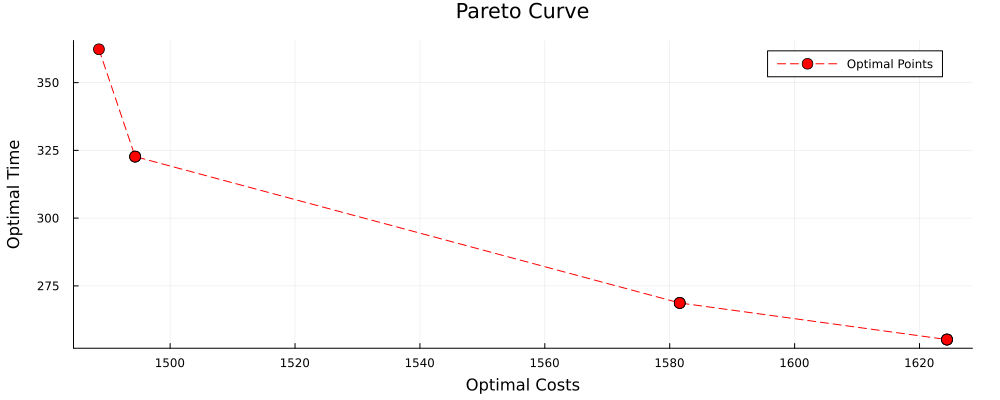

In [15]:
# Plot Pareto Curve
p1 = plot(opt_costs, opt_times, marker=:circle, markersize=6, 
          label="Optimal Points", color=:red, line=:dash)
title!(p1, "Pareto Curve")
xlabel!(p1, "Optimal Costs")
ylabel!(p1, "Optimal Time")


# Display
plot(p1, layout=(1,2), size=(1000, 400), margin=5Plots.mm)

## Big next steps:
* Start writing the report
* Add maximum repair times at each node
* Add time phasing (level 3) [will have to make some consequence between days as otherwise could be reduced to one day lump demand]
* Maybe add basic part component which can be used to "repair" (buy) part components and so demand can always be filled [must make cost great enough that repairs only done in worst case.]

Time is acting as work-hours, so maybe assign workers to each node to multiply by work capacity.


* In general go over naming of columns and organization
* revamp costs to martignal amounts or bulk amount.
* change column name of repair_cost_multiplier to repair_cost_mult in comp_mult_df
* component_multipler.csv multiplier spelled incorrect
* multipliers at local shops?
* add repair_difficulty to bom.csv instead of components.csv (or keep it in components.csv)
  also part components are never repaired and so do not need a repair difficulty

* put repair times in BOM?
* add transport time for each arc and multiplier seperat in arc.csv
* increase number of demands for more interesting outputs...
  otherwise cannot see how limits on shop capacity impact as too few things need to be repaired
* similarly, maybe add more nodes for each level for repair difficulty/shop capability seen better

---
# <center>Citations</center>

Sherbrooke, C. C. (2004). *Optimal inventory modeling of systems* (2nd ed.). Kluwer Academic. (International Series in Operations Research & Management Science).